<a href="https://colab.research.google.com/github/Tahsin22201243/Machine-Learning/blob/main/Mega3_22201243.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
import random
import re
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader,
    TensorDataset,
    WeightedRandomSampler
)

from torchvision import transforms
import torchvision.transforms.functional as Ff

from sklearn.datasets import (
    load_digits,
    fetch_20newsgroups
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


In [8]:
import numpy as np
import torch
import  torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_lfw_people

**Part A**
Qns 1

In [51]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

#Qns 1

data = load_wine()

X = data.data
y = data.target

print("Original Shape:", X.shape)

#Qns 2
class_1_idx = np.where(y == 1)[0]
other_idx = np.where(y != 1)[0]

np.random.seed(42)

keep_class1 = np.random.choice(
    class_1_idx,
    size=int(0.25 * len(class_1_idx)),
    replace=False
)

final_idx = np.concatenate([keep_class1, other_idx])


np.random.shuffle(final_idx)


X = X[final_idx]
y = y[final_idx]

print("After Imbalance:", X.shape)

#Qns 3

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

#Qns 4
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

#Qns 5

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

#Qns 6

class_counts = np.bincount(y_train.numpy())

weights = 1.0 / class_counts

sample_weights = weights[y_train.numpy()]

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

#Qns 7

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

#Qns 8

input_size = X_train.shape[1]
num_classes = len(torch.unique(y_train))

class DNN(nn.Module):

    def __init__(self):
        super(DNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = DNN()

print(model)

#Qns 9

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

#Qns 10
def accuracy(loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            outputs = model(X_batch)

            _, predicted = torch.max(outputs, 1)

            total += y_batch.size(0)

            correct += (predicted == y_batch).sum().item()

    return 100 * correct / total

#Qns 11

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_acc = accuracy(train_loader)
    val_acc = accuracy(val_loader)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Loss: {running_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print("-" * 40)
#Qns 12

test_acc = accuracy(test_loader)

print(f"Final Test Accuracy: {test_acc:.2f}%")

Original Shape: (178, 13)
After Imbalance: (124, 13)
Train: (86, 13)
Validation: (19, 13)
Test: (19, 13)
DNN(
  (model): Sequential(
    (0): Linear(in_features=13, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)
Epoch [1/5]
Loss: 82.3177
Train Accuracy: 36.05%
Validation Accuracy: 10.53%
----------------------------------------
Epoch [2/5]
Loss: 54.1411
Train Accuracy: 41.86%
Validation Accuracy: 47.37%
----------------------------------------
Epoch [3/5]
Loss: 80.9533
Train Accuracy: 31.40%
Validation Accuracy: 47.37%
----------------------------------------
Epoch [4/5]
Loss: 37.6056
Train Accuracy: 33.72%
Validation Accuracy: 42.11%
----------------------------------------
Epoch [5/5]
Loss: 22.1426
Train Accuracy: 45.35%
Validation Accuracy: 52.63%
----------------------------------------
Final Test Accuracy: 57.89%


**Part B Qns 2**

Image Shape: torch.Size([8, 3, 96, 96])


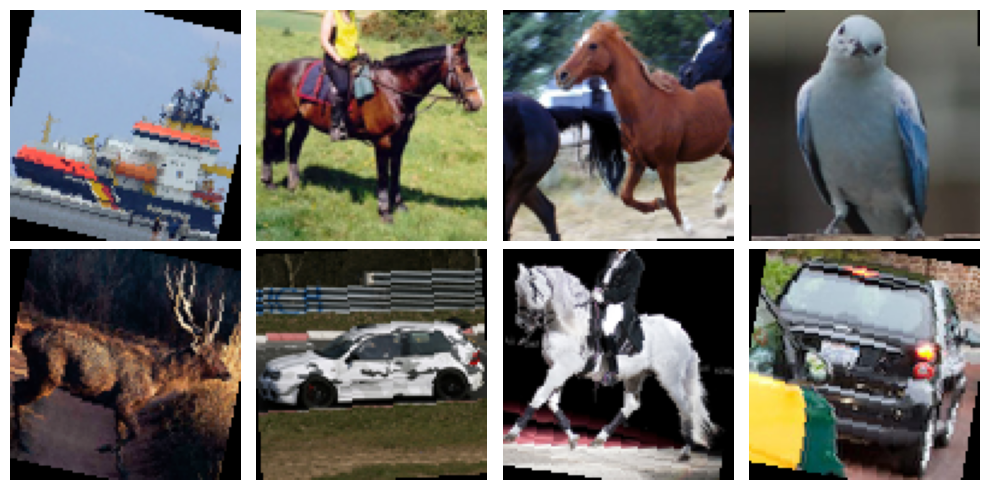

In [50]:

import torch
import torchvision
import matplotlib.pyplot as plt

from torchvision import transforms
from torch.utils.data import DataLoader

#Qns1

train_transform = transforms.Compose([

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ToTensor()
])

#Qns2

train_dataset = torchvision.datasets.STL10(
    root='./data',
    split='train',
    download=True,
    transform=train_transform
)

#Qns3
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

#Qns4

images, labels = next(iter(train_loader))

print("Image Shape:", images.shape)

#Qns5

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i in range(8):

    img = images[i].permute(1, 2, 0)

    ax = axes[i // 4, i % 4]

    ax.imshow(img)

    ax.axis("off")

plt.tight_layout()

plt.show()

Part C Qns 3

In [54]:
import pandas as pd
import numpy as np
import re

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader



df = pd.read_csv("/content/tweets.csv")

print(df.head())
print("Available columns:", df.columns.tolist())



disaster_keywords = [
    "earthquake",
    "flood",
    "fire",
    "hurricane",
    "tsunami",
    "explosion",
    "disaster",
    "storm"
]

def create_label(text):

    text = str(text).lower()

    for word in disaster_keywords:

        if word in text:
            return 1

    return 0


df['TargetEncoder'] = df['content'].apply(create_label)


# Extract text and labels
texts = df['content'].astype(str).values
labels = df['TargetEncoder'].values

print(df[['content', 'TargetEncoder']].head())

      author                                            content country  \
0  katyperry  Is history repeating itself...?#DONTNORMALIZEH...     NaN   
1  katyperry  @barackobama Thank you for your incredible gra...     NaN   
2  katyperry                Life goals. https://t.co/XIn1qKMKQl     NaN   
3  katyperry            Me right now 🙏🏻 https://t.co/gW55C1wrwd     NaN   
4  katyperry  SISTERS ARE DOIN' IT FOR THEMSELVES! 🙌🏻💪🏻❤️ ht...     NaN   

          date_time            id language  latitude  longitude  \
0  12/01/2017 19:52  8.196330e+17       en       NaN        NaN   
1  11/01/2017 08:38  8.191010e+17       en       NaN        NaN   
2  11/01/2017 02:52  8.190140e+17       en       NaN        NaN   
3  11/01/2017 02:44  8.190120e+17       en       NaN        NaN   
4  10/01/2017 05:22  8.186890e+17       en       NaN        NaN   

   number_of_likes  number_of_shares  
0             7900              3472  
1             3689              1380  
2            10341           

**Part D**

In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(96, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))

        x = torch.flatten(x, 1)

        print(x.shape)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x


model = CNN()